In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score)
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded ✅")

Libraries loaded ✅


In [ ]:
df = pd.read_csv("delay_features.csv")

print("Shape:", df.shape)
print("\nTarget distribution:")
print(df['Late_delivery_risk'].value_counts())
print(f"\nLate delivery rate: {df['Late_delivery_risk'].mean()*100:.1f}%")

Shape: (180519, 12)

Target distribution:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Late delivery rate: 54.8%


In [ ]:
X = df.drop(columns=['Late_delivery_risk'])
y = df['Late_delivery_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size   = 0.2,
    random_state= 42,
    stratify    = y      # keeps same late/ontime ratio in both splits
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (144415, 11)
Test size : (36104, 11)


In [ ]:
model = XGBClassifier(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    eval_metric      = 'logloss'
)

model.fit(X_train, y_train, verbose=False)
print("Model trained ✅")

Model trained ✅


In [ ]:
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print("=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_test, y_pred,
    target_names=['On Time', 'Late']
))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}")

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     On Time       0.62      0.87      0.72     16308
        Late       0.84      0.56      0.67     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.71      0.70     36104
weighted avg       0.74      0.70      0.69     36104

ROC-AUC Score: 0.7375


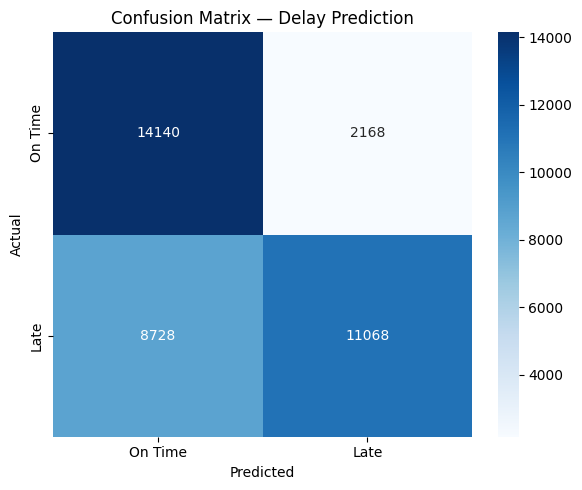

Plot saved ✅


In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On Time', 'Late'],
            yticklabels=['On Time', 'Late'])
plt.title('Confusion Matrix — Delay Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig("delay_confusion_matrix.png")
plt.show()
print("Plot saved ✅")

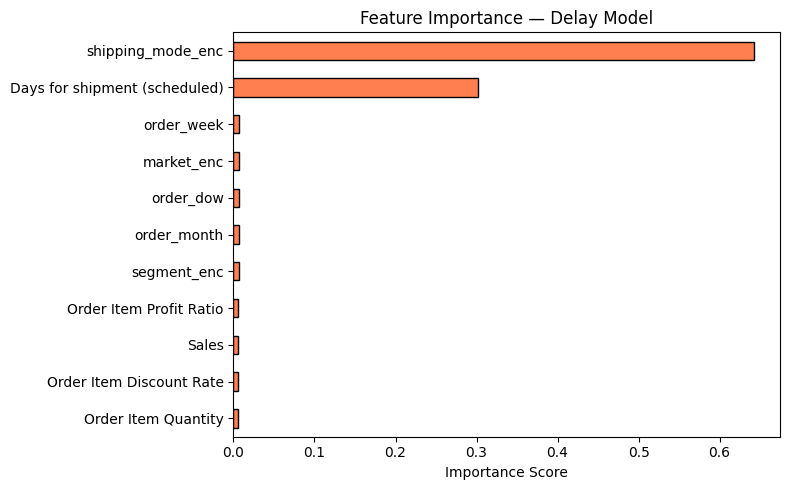

In [ ]:
feat_imp = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh', color='coral', edgecolor='black')
plt.title('Feature Importance — Delay Model')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig("delay_feature_importance.png")
plt.show()

In [ ]:
joblib.dump(model, "delay_model.pkl")
print("Model saved ✅ → delay_model.pkl")

output = pd.DataFrame({
    'actual'           : y_test.values,
    'predicted'        : y_pred,
    'delay_probability': y_pred_prob
})
output.to_csv("delay_predictions.csv", index=False)
print("Predictions saved ✅ → delay_predictions.csv")
print(output.head())

Model saved ✅ → delay_model.pkl
Predictions saved ✅ → delay_predictions.csv
   actual  predicted  delay_probability
0       0          0           0.443591
1       0          0           0.405560
2       0          0           0.398259
3       0          0           0.388092
4       1          1           0.542879


In [ ]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, y_pred_prob)

print("=" * 40)
print("  DELAY PREDICTION COMPLETE")
print("=" * 40)
print(f"  ROC-AUC      : {auc:.4f}")
print(f"  Train rows   : {len(X_train)}")
print(f"  Test rows    : {len(X_test)}")
print(f"  Model saved  : delay_model.pkl")
print(f"  Output saved : delay_predictions.csv")
print("=" * 40)

  DELAY PREDICTION COMPLETE
  ROC-AUC      : 0.7375
  Train rows   : 144415
  Test rows    : 36104
  Model saved  : delay_model.pkl
  Output saved : delay_predictions.csv
